In [59]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [60]:
# file_path = '/content/drive/MyDrive/Colab Notebooks/HW06'
# with open(file_path, 'r') as file:
#     data = file.read()
import os

os.listdir('/content/drive/MyDrive/Colab Notebooks/HW07/data')

['S07-hw-dataset-01.csv', 'S07-hw-dataset-02.csv', 'S07-hw-dataset-03.csv']

In [61]:
# Импорты: только стандартные библиотеки + scikit-learn
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# Базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#2
DATA01_PATH = "/content/drive/MyDrive/Colab Notebooks/HW07/data/S07-hw-dataset-01.csv"
DATA02_PATH = "/content/drive/MyDrive/Colab Notebooks/HW07/data/S07-hw-dataset-02.csv"
DATA03_PATH = "/content/drive/MyDrive/Colab Notebooks/HW07/data/S07-hw-dataset-03.csv"

df1 = pd.read_csv(DATA01_PATH)
df2 = pd.read_csv(DATA02_PATH)
df3 = pd.read_csv(DATA03_PATH)

In [62]:
# 2. Анализируем первый датасет
print("=== DATASET 01 ===")
print("\nhead():")
print(df1.head())

print("\ninfo():")
print(df1.info())

print("\ndescribe():")
print(df1.describe(include='all'))

print("\nПропуски:")
print(df1.isnull().sum())

print("\nТипы признаков:")
print(f"Числовые: {df1.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"Категориальные: {df1.select_dtypes(exclude=[np.number]).columns.tolist()}")

=== DATASET 01 ===

head():
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056  61.833444 -0.022466  -42.631335   3.107154   

         f06        f07       f08  
0 -12.291287  -6.836847 -0.504094  
1  34.316967 -49.468873  0.390356  
2  25.892951  44.595250  0.325893  
3   2.014316 -39.930582  0.139297  
4  -5.471054   7.001149  0.131213  

info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03    

In [63]:
# 2. Анализируем первый датасет
print("=== DATASET 02 ===")
print("\nhead():")
print(df2.head())

print("\ninfo():")
print(df2.info())

print("\ndescribe():")
print(df2.describe(include='all'))

print("\nПропуски:")
print(df2.isnull().sum())

print("\nТипы признаков:")
print(f"Числовые: {df2.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"Категориальные: {df2.select_dtypes(exclude=[np.number]).columns.tolist()}")

=== DATASET 02 ===

head():
   sample_id        x1        x2    z_noise
0          0  0.098849 -1.846034  21.288122
1          1 -1.024516  1.829616   6.072952
2          2 -1.094178 -0.158545 -18.938342
3          3 -1.612808 -1.565844 -11.629462
4          4  1.659901 -2.133292   1.895472

info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB
None

describe():
        sample_id           x1           x2      z_noise
count  8000.00000  8000.000000  8000.000000  8000.000000
mean   3999.50000     0.478867     0.241112     0.110454
std    2309.54541     0.955138     0.663195     8.097716
min       0.00000    -2.487352    -2.499237   -34.05607

In [64]:
# 2. Анализируем первый датасет
print("=== DATASET 03 ===")
print("\nhead():")
print(df3.head())

print("\ninfo():")
print(df3.info())

print("\ndescribe():")
print(df3.describe(include='all'))

print("\nПропуски:")
print(df3.isnull().sum())

print("\nТипы признаков:")
print(f"Числовые: {df3.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"Категориальные: {df3.select_dtypes(exclude=[np.number]).columns.tolist()}")

=== DATASET 03 ===

head():
   sample_id        x1        x2    f_corr   f_noise
0          0 -2.710470  4.997107 -1.015703  0.718508
1          1  8.730238 -8.787416  3.953063 -1.105349
2          2 -1.079600 -2.558708  0.976628 -3.605776
3          3  6.854042  1.560181  1.760614 -1.230946
4          4  9.963812 -8.869921  2.966583  0.915899

info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB
None

describe():
          sample_id            x1            x2        f_corr       f_noise
count  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000
mean    7499.500000      1.246296  

In [65]:
# Для df1
X_df1 = df1.drop('sample_id', axis=1)
sample_ids_df1 = df1['sample_id']

# Для df2
X_df2 = df2.drop('sample_id', axis=1)
sample_ids_df2 = df2['sample_id']

# Для df3
X_df3 = df3.drop('sample_id', axis=1)
sample_ids_df3 = df3['sample_id']

print("Разделение признаков (X) и sample_id выполнено для df1, df2, df3.")

Разделение признаков (X) и sample_id выполнено для df1, df2, df3.


##2.3.2. Препроцессинг

In [66]:
from sklearn.impute import SimpleImputer

# Функция для препроцессинга с проверкой на пропуски
def preprocess_data_with_imputation_and_scaling(df_features, df_name):
    print(f"\n--- Препроцессинг {df_name} ---")

    # Проверка на пропущенные значения
    missing_values_count = df_features.isnull().sum().sum()
    if missing_values_count > 0:
        print(f"Обнаружено {missing_values_count} пропущенных значений. Применяем SimpleImputer...")
        imputer = SimpleImputer(strategy='mean')
        df_features_imputed = imputer.fit_transform(df_features)
        print("Пропущенные значения обработаны.")
    else:
        print("Пропущенных значений не обнаружено.")
        df_features_imputed = df_features.copy()

    # Масштабирование числовых признаков
    scaler = StandardScaler()
    df_features_scaled = scaler.fit_transform(df_features_imputed)
    print("Данные масштабированы с помощью StandardScaler.")

    return df_features_scaled

# Применяем функцию к каждому датасету
X_df1_scaled_imputed = preprocess_data_with_imputation_and_scaling(X_df1, 'X_df1')
X_df2_scaled_imputed = preprocess_data_with_imputation_and_scaling(X_df2, 'X_df2')
X_df3_scaled_imputed = preprocess_data_with_imputation_and_scaling(X_df3, 'X_df3')



--- Препроцессинг X_df1 ---
Пропущенных значений не обнаружено.
Данные масштабированы с помощью StandardScaler.

--- Препроцессинг X_df2 ---
Пропущенных значений не обнаружено.
Данные масштабированы с помощью StandardScaler.

--- Препроцессинг X_df3 ---
Пропущенных значений не обнаружено.
Данные масштабированы с помощью StandardScaler.


##2.3.3. Модели недели 7

##KMeans

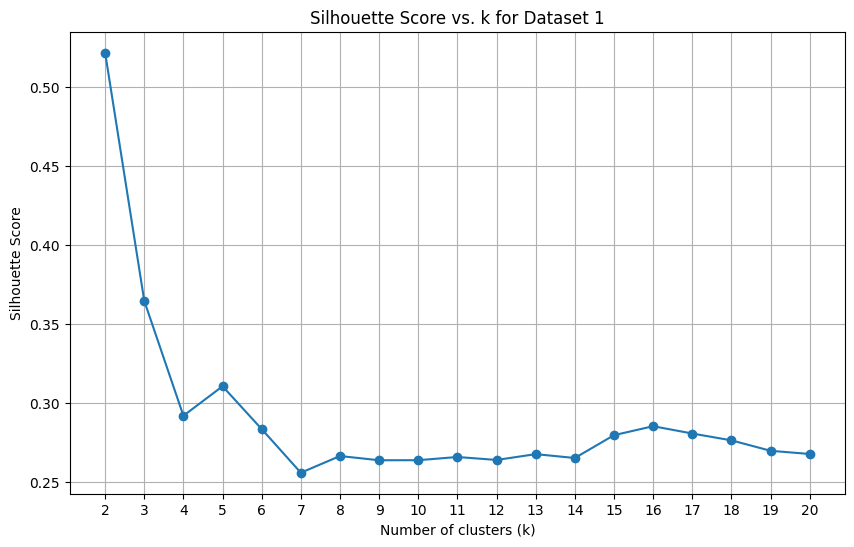

Silhouette scores calculated and plotted for Dataset 1.


In [67]:
silhouette_scores_df1 = []
k_range = range(2, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_df1_scaled_imputed)
    labels = kmeans.predict(X_df1_scaled_imputed)
    silhouette_avg = silhouette_score(X_df1_scaled_imputed, labels)
    silhouette_scores_df1.append(silhouette_avg)

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores_df1, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k for Dataset 1')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

print("Silhouette scores calculated and plotted for Dataset 1.")

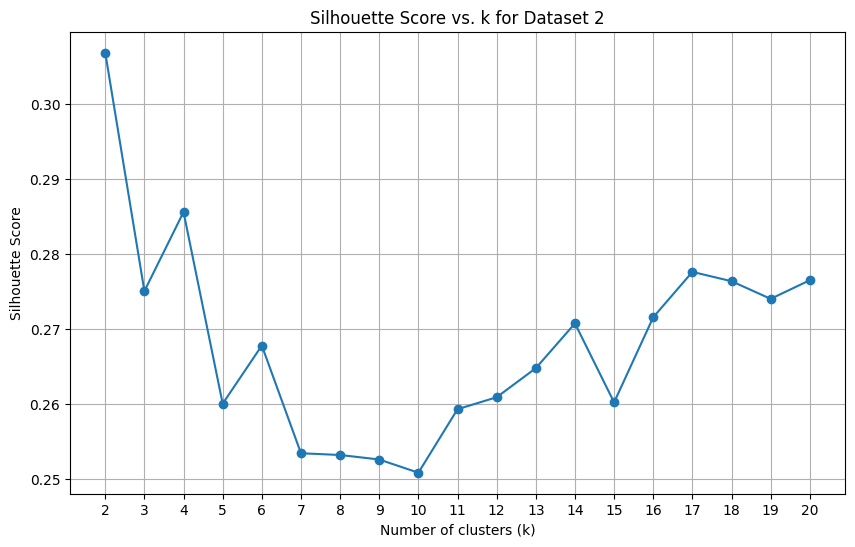

Silhouette scores calculated and plotted for Dataset 2.


In [68]:
silhouette_scores_df2 = []
k_range = range(2, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_df2_scaled_imputed)
    labels = kmeans.predict(X_df2_scaled_imputed)
    silhouette_avg = silhouette_score(X_df2_scaled_imputed, labels)
    silhouette_scores_df2.append(silhouette_avg)

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores_df2, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k for Dataset 2')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

print("Silhouette scores calculated and plotted for Dataset 2.")

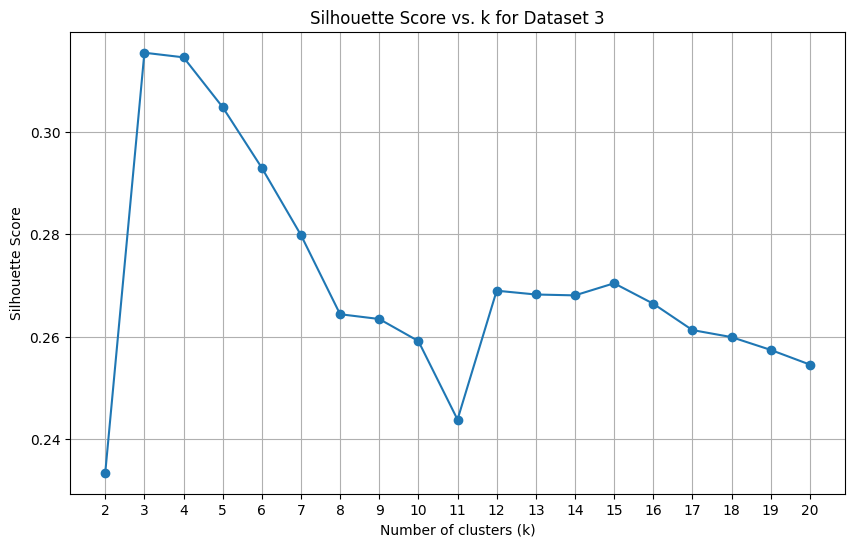

Silhouette scores calculated and plotted for Dataset 3.


In [69]:
silhouette_scores_df3 = []
k_range = range(2, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_df3_scaled_imputed)
    labels = kmeans.predict(X_df3_scaled_imputed)
    silhouette_avg = silhouette_score(X_df3_scaled_imputed, labels)
    silhouette_scores_df3.append(silhouette_avg)

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores_df3, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k for Dataset 3')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

print("Silhouette scores calculated and plotted for Dataset 3.")

##DBSCAN

k-расстояний для X_df1_scaled_imputed с k = 5...


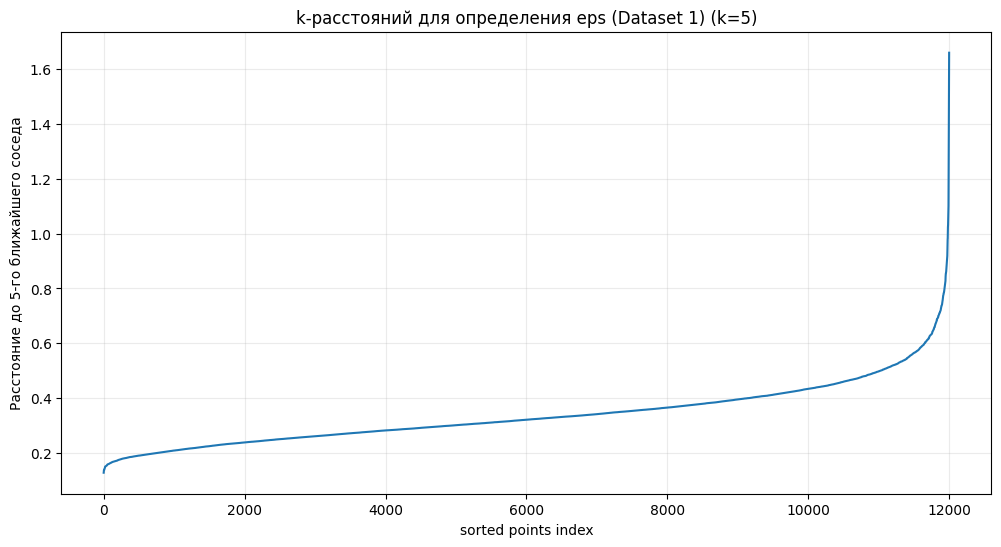

In [70]:
def k_distance_plot(X, k=8, title="k-distance plot"):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)

    kth_distances = np.sort(distances[:, -1])

    plt.figure(figsize=(12, 6))
    plt.plot(kth_distances)
    plt.title(f"{title} (k={k})")
    plt.xlabel("sorted points index")
    plt.ylabel(f"Расстояние до {k}-го ближайшего соседа")
    plt.grid(True, alpha=0.25)
    plt.show()

    return kth_distances

min_samples_k_dist = 5
print(f"k-расстояний для X_df1_scaled_imputed с k = {min_samples_k_dist}...")
kth_distances_df1 = k_distance_plot(X_df1_scaled_imputed, k=min_samples_k_dist, title='k-расстояний для определения eps (Dataset 1)')


### Применение DBSCAN к Dataset 1 (`X_df1_scaled_imputed`)

In [71]:
from sklearn.cluster import DBSCAN

# Параметры, выбранные после анализа k-distance plot
eps_df1 = 0.6
min_samples_df1 = min_samples_k_dist # Используем тот же min_samples

print(f"Применение DBSCAN к X_df1_scaled_imputed с eps={eps_df1} и min_samples={min_samples_df1}...")

dbscan_df1 = DBSCAN(eps=eps_df1, min_samples=min_samples_df1)
clusters_df1 = dbscan_df1.fit_predict(X_df1_scaled_imputed)

# Количество кластеров, игнорируя шумовые точки (-1)
num_clusters_df1 = len(set(clusters_df1)) - (1 if -1 in clusters_df1 else 0)

# Количество шумовых точек
num_noise_df1 = list(clusters_df1).count(-1)

print(f"\nРезультаты DBSCAN для Dataset 1:")
print(f"  Количество кластеров: {num_clusters_df1}")
print(f"  Количество шумовых точек: {num_noise_df1}")

# Расчет Silhouette Score, если есть более одного кластера (и не все точки шум)
if num_clusters_df1 > 1 and num_clusters_df1 < len(X_df1_scaled_imputed):
    silhouette_avg_dbscan_df1 = silhouette_score(X_df1_scaled_imputed, clusters_df1)
    print(f"  Silhouette Score: {silhouette_avg_dbscan_df1:.3f}")
else:
    print("  Silhouette Score не может быть рассчитан (слишком мало кластеров или все точки - шум).")


Применение DBSCAN к X_df1_scaled_imputed с eps=0.6 и min_samples=5...

Результаты DBSCAN для Dataset 1:
  Количество кластеров: 5
  Количество шумовых точек: 130
  Silhouette Score: 0.371


##2.3.4

## Метрики KMeans для Dataset 1

In [72]:
kmeans_df1_k2 = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_df1_k2.fit(X_df1_scaled_imputed)
labels_df1_k2 = kmeans_df1_k2.labels_

silhouette_avg_df1_k2 = silhouette_score(X_df1_scaled_imputed, labels_df1_k2)
davies_bouldin_avg_df1_k2 = davies_bouldin_score(X_df1_scaled_imputed, labels_df1_k2)
calinski_harabasz_avg_df1_k2 = calinski_harabasz_score(X_df1_scaled_imputed, labels_df1_k2)

print(f"Результаты KMeans для Dataset 1 (k=2):\n")
print(f"  Silhouette Score: {silhouette_avg_df1_k2:.3f}")
print(f"  Davies-Bouldin Score: {davies_bouldin_avg_df1_k2:.3f}")
print(f"  Calinski-Harabasz Score: {calinski_harabasz_avg_df1_k2:.3f}")

Результаты KMeans для Dataset 1 (k=2):

  Silhouette Score: 0.522
  Davies-Bouldin Score: 0.685
  Calinski-Harabasz Score: 11786.955


## Метрики KMeans для Dataset 2

In [73]:
kmeans_df2_k3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_df2_k3.fit(X_df2_scaled_imputed)
labels_df2_k3 = kmeans_df2_k3.labels_

silhouette_avg_df2_k3 = silhouette_score(X_df2_scaled_imputed, labels_df2_k3)
davies_bouldin_avg_df2_k3 = davies_bouldin_score(X_df2_scaled_imputed, labels_df2_k3)
calinski_harabasz_avg_df2_k3 = calinski_harabasz_score(X_df2_scaled_imputed, labels_df2_k3)

print(f"Результаты KMeans для Dataset 2 (k=3):\n")
print(f"  Silhouette Score: {silhouette_avg_df2_k3:.3f}")
print(f"  Davies-Bouldin Score: {davies_bouldin_avg_df2_k3:.3f}")
print(f"  Calinski-Harabasz Score: {calinski_harabasz_avg_df2_k3:.3f}")

Результаты KMeans для Dataset 2 (k=3):

  Silhouette Score: 0.275
  Davies-Bouldin Score: 1.225
  Calinski-Harabasz Score: 3077.719


# Task
```python
kmeans_df3_k3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_df3_k3.fit(X_df3_scaled_imputed)
labels_df3_k3 = kmeans_df3_k3.labels_

silhouette_avg_df3_k3 = silhouette_score(X_df3_scaled_imputed, labels_df3_k3)
davies_bouldin_avg_df3_k3 = davies_bouldin_score(X_df3_scaled_imputed, labels_df3_k3)
calinski_harabasz_avg_df3_k3 = calinski_harabasz_score(X_df3_scaled_imputed, labels_df3_k3)

print(f"Результаты KMeans для Dataset 3 (k=3):\n")
print(f"  Silhouette Score: {silhouette_avg_df3_k3:.3f}")
print(f"  Davies-Bouldin Score: {davies_bouldin_avg_df3_k3:.3f}")
print(f"  Calinski-Harabasz Score: {calinski_harabasz_avg_df3_k3:.3f}")
```

## Метрики KMeans для Датасета 3


In [74]:
kmeans_df3_k3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_df3_k3.fit(X_df3_scaled_imputed)
labels_df3_k3 = kmeans_df3_k3.labels_

silhouette_avg_df3_k3 = silhouette_score(X_df3_scaled_imputed, labels_df3_k3)
davies_bouldin_avg_df3_k3 = davies_bouldin_score(X_df3_scaled_imputed, labels_df3_k3)
calinski_harabasz_avg_df3_k3 = calinski_harabasz_score(X_df3_scaled_imputed, labels_df3_k3)

print(f"Результаты KMeans для Dataset 3 (k=3):\n")
print(f"  Silhouette Score: {silhouette_avg_df3_k3:.3f}")
print(f"  Davies-Bouldin Score: {davies_bouldin_avg_df3_k3:.3f}")
print(f"  Calinski-Harabasz Score: {calinski_harabasz_avg_df3_k3:.3f}")

Результаты KMeans для Dataset 3 (k=3):

  Silhouette Score: 0.316
  Davies-Bouldin Score: 1.158
  Calinski-Harabasz Score: 6957.158


## Завершение метрик DBSCAN для Датасета 1

In [75]:
print("\n--- Метрики DBSCAN для Dataset 1 (без шумовых точек) ---")

# Создаем булеву маску для нешумовых точек
non_noise_mask = (clusters_df1 != -1)

# Отфильтровываем данные и метки кластеров
X_filtered_df1 = X_df1_scaled_imputed[non_noise_mask]
labels_filtered_df1 = clusters_df1[non_noise_mask]

# Количество кластеров после удаления шума
num_clusters_filtered_df1 = len(set(labels_filtered_df1)) - (1 if -1 in labels_filtered_df1 else 0)

# Проверка, достаточно ли кластеров для расчета метрик
if num_clusters_filtered_df1 > 1:
    davies_bouldin_avg_dbscan_df1 = davies_bouldin_score(X_filtered_df1, labels_filtered_df1)
    calinski_harabasz_avg_dbscan_df1 = calinski_harabasz_score(X_filtered_df1, labels_filtered_df1)
    print(f"  Davies-Bouldin Score (без шума): {davies_bouldin_avg_dbscan_df1:.3f}")
    print(f"  Calinski-Harabasz Score (без шума): {calinski_harabasz_avg_dbscan_df1:.3f}")
else:
    print("  Недостаточно кластеров (без шума) для расчета Davies-Bouldin Score и Calinski-Harabasz Score.")

# Рассчитываем долю шумовых точек
total_points_df1 = len(clusters_df1)
proportion_noise_df1 = num_noise_df1 / total_points_df1

print(f"  Доля шумовых точек: {proportion_noise_df1:.3f} ({num_noise_df1}/{total_points_df1}) ")


--- Метрики DBSCAN для Dataset 1 (без шумовых точек) ---
  Davies-Bouldin Score (без шума): 1.252
  Calinski-Harabasz Score (без шума): 8432.693
  Доля шумовых точек: 0.011 (130/12000) 


## Построение k-дистанционного графика DBSCAN для Датасета 2

k-расстояний для X_df2_scaled_imputed с k = 5...


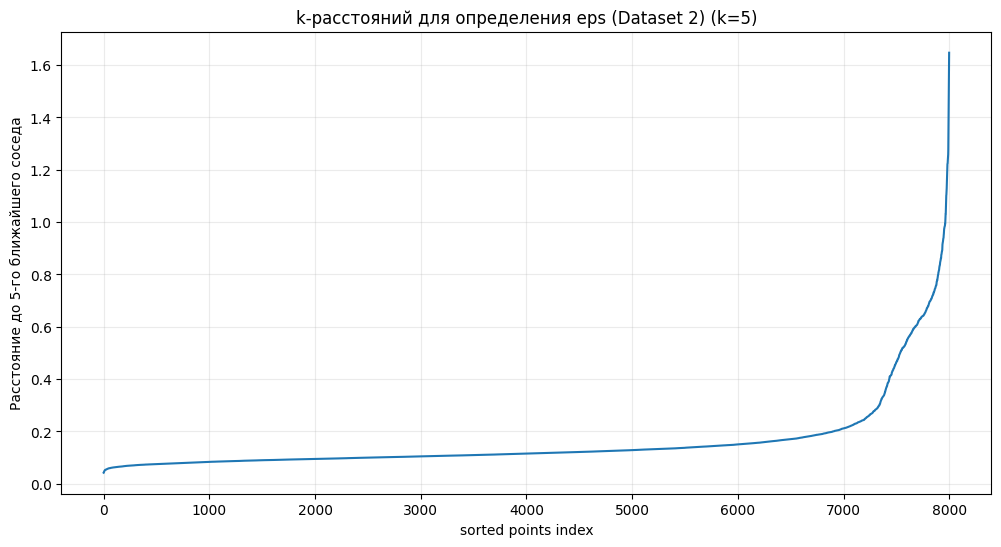

In [76]:
print(f"k-расстояний для X_df2_scaled_imputed с k = {min_samples_k_dist}...")
kth_distances_df2 = k_distance_plot(X_df2_scaled_imputed, k=min_samples_k_dist, title='k-расстояний для определения eps (Dataset 2)')

In [77]:
print(f"\n--- Применение DBSCAN к Dataset 2 ---")

# Параметры DBSCAN для X_df2_scaled_imputed
# eps может быть выбран из "изгиба" на графике k-расстояний. Для примера, возьмем 0.2
eps_df2 = 0.2
min_samples_df2 = min_samples_k_dist # Используем тот же min_samples = 5

print(f"Применение DBSCAN к X_df2_scaled_imputed с eps={eps_df2} и min_samples={min_samples_df2}...")

dbscan_df2 = DBSCAN(eps=eps_df2, min_samples=min_samples_df2)
clusters_df2 = dbscan_df2.fit_predict(X_df2_scaled_imputed)

# Количество кластеров, игнорируя шумовые точки (-1)
num_clusters_df2 = len(set(clusters_df2)) - (1 if -1 in clusters_df2 else 0)

# Количество шумовых точек
num_noise_df2 = list(clusters_df2).count(-1)

print(f"\nРезультаты DBSCAN для Dataset 2:")
print(f"  Количество кластеров: {num_clusters_df2}")
print(f"  Количество шумовых точек: {num_noise_df2}")

# Расчет Silhouette Score, если есть более одного кластера (и не все точки шум)
if num_clusters_df2 > 1 and num_clusters_df2 < len(X_df2_scaled_imputed):
    silhouette_avg_dbscan_df2 = silhouette_score(X_df2_scaled_imputed, clusters_df2)
    print(f"  Silhouette Score: {silhouette_avg_dbscan_df2:.3f}")
else:
    print("  Silhouette Score не может быть рассчитан (слишком мало кластеров или все точки - шум).")


--- Применение DBSCAN к Dataset 2 ---
Применение DBSCAN к X_df2_scaled_imputed с eps=0.2 и min_samples=5...

Результаты DBSCAN для Dataset 2:
  Количество кластеров: 9
  Количество шумовых точек: 816
  Silhouette Score: -0.082


In [78]:
print("\n--- Метрики DBSCAN для Dataset 2 (без шумовых точек) ---")

# Создаем булеву маску для нешумовых точек
non_noise_mask_df2 = (clusters_df2 != -1)

# Отфильтровываем данные и метки кластеров
X_filtered_df2 = X_df2_scaled_imputed[non_noise_mask_df2]
labels_filtered_df2 = clusters_df2[non_noise_mask_df2]

# Количество кластеров после удаления шума
num_clusters_filtered_df2 = len(set(labels_filtered_df2)) - (1 if -1 in labels_filtered_df2 else 0)

# Проверка, достаточно ли кластеров для расчета метрик
if num_clusters_filtered_df2 > 1:
    davies_bouldin_avg_dbscan_df2 = davies_bouldin_score(X_filtered_df2, labels_filtered_df2)
    calinski_harabasz_avg_dbscan_df2 = calinski_harabasz_score(X_filtered_df2, labels_filtered_df2)
    print(f"  Davies-Bouldin Score (без шума): {davies_bouldin_avg_dbscan_df2:.3f}")
    print(f"  Calinski-Harabasz Score (без шума): {calinski_harabasz_avg_dbscan_df2:.3f}")
else:
    print("  Недостаточно кластеров (без шума) для расчета Davies-Bouldin Score и Calinski-Harabasz Score.")

# Рассчитываем долю шумовых точек
total_points_df2 = len(clusters_df2)
proportion_noise_df2 = num_noise_df2 / total_points_df2

print(f"  Доля шумовых точек: {proportion_noise_df2:.3f} ({num_noise_df2}/{total_points_df2}) ")


--- Метрики DBSCAN для Dataset 2 (без шумовых точек) ---
  Davies-Bouldin Score (без шума): 0.792
  Calinski-Harabasz Score (без шума): 377.858
  Доля шумовых точек: 0.102 (816/8000) 


k-расстояний для X_df3_scaled_imputed с k = 5...


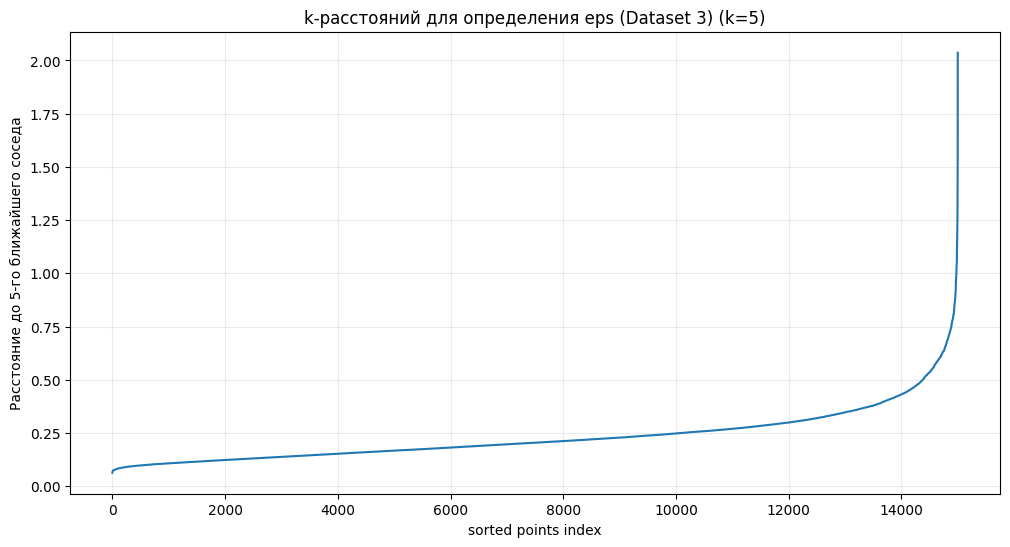

In [79]:
print(f"k-расстояний для X_df3_scaled_imputed с k = {min_samples_k_dist}...")
kth_distances_df3 = k_distance_plot(X_df3_scaled_imputed, k=min_samples_k_dist, title='k-расстояний для определения eps (Dataset 3)')

In [80]:
print(f"\n--- Применение DBSCAN к Dataset 3 ---")

# Параметры DBSCAN для X_df3_scaled_imputed
# eps может быть выбран из "изгиба" на графике k-расстояний. Для примера, возьмем 0.2
eps_df3 = 0.25 # Adjust based on visual inspection of the k-distance plot for df3
min_samples_df3 = min_samples_k_dist # Используем тот же min_samples = 5

print(f"Применение DBSCAN к X_df3_scaled_imputed с eps={eps_df3} и min_samples={min_samples_df3}...")

dbscan_df3 = DBSCAN(eps=eps_df3, min_samples=min_samples_df3)
clusters_df3 = dbscan_df3.fit_predict(X_df3_scaled_imputed)

# Количество кластеров, игнорируя шумовые точки (-1)
num_clusters_df3 = len(set(clusters_df3)) - (1 if -1 in clusters_df3 else 0)

# Количество шумовых точек
num_noise_df3 = list(clusters_df3).count(-1)

print(f"\nРезультаты DBSCAN для Dataset 3:")
print(f"  Количество кластеров: {num_clusters_df3}")
print(f"  Количество шумовых точек: {num_noise_df3}")

# Расчет Silhouette Score, если есть более одного кластера (и не все точки шум)
if num_clusters_df3 > 1 and num_clusters_df3 < len(X_df3_scaled_imputed):
    silhouette_avg_dbscan_df3 = silhouette_score(X_df3_scaled_imputed, clusters_df3)
    print(f"  Silhouette Score: {silhouette_avg_dbscan_df3:.3f}")
else:
    print("  Silhouette Score не может быть рассчитан (слишком мало кластеров или все точки - шум).")


--- Применение DBSCAN к Dataset 3 ---
Применение DBSCAN к X_df3_scaled_imputed с eps=0.25 и min_samples=5...

Результаты DBSCAN для Dataset 3:
  Количество кластеров: 63
  Количество шумовых точек: 3362
  Silhouette Score: -0.367


In [81]:
print("--- Метрики DBSCAN для Dataset 3 (без шумовых точек) ---")

# Создаем булеву маску для нешумовых точек
non_noise_mask_df3 = (clusters_df3 != -1)

# Отфильтровываем данные и метки кластеров
X_filtered_df3 = X_df3_scaled_imputed[non_noise_mask_df3]
labels_filtered_df3 = clusters_df3[non_noise_mask_df3]

# Количество кластеров после удаления шума
num_clusters_filtered_df3 = len(set(labels_filtered_df3)) - (1 if -1 in labels_filtered_df3 else 0)

# Проверка, достаточно ли кластеров для расчета метрик
if num_clusters_filtered_df3 > 1:
    davies_bouldin_avg_dbscan_df3 = davies_bouldin_score(X_filtered_df3, labels_filtered_df3)
    calinski_harabasz_avg_dbscan_df3 = calinski_harabasz_score(X_filtered_df3, labels_filtered_df3)
    print(f"  Davies-Bouldin Score (без шума): {davies_bouldin_avg_dbscan_df3:.3f}")
    print(f"  Calinski-Harabasz Score (без шума): {calinski_harabasz_avg_dbscan_df3:.3f}")
else:
    print("  Недостаточно кластеров (без шума) для расчета Davies-Bouldin Score и Calinski-Harabasz Score.")

# Рассчитываем долю шумовых точек
total_points_df3 = len(clusters_df3)
proportion_noise_df3 = num_noise_df3 / total_points_df3

print(f"  Доля шумовых точек: {proportion_noise_df3:.3f} ({num_noise_df3}/{total_points_df3}) ")

--- Метрики DBSCAN для Dataset 3 (без шумовых точек) ---
  Davies-Bouldin Score (без шума): 0.987
  Calinski-Harabasz Score (без шума): 223.084
  Доля шумовых точек: 0.224 (3362/15000) 


In [82]:
print("--- Метрики DBSCAN для Dataset 3 (без шумовых точек) ---")

# Создаем булеву маску для нешумовых точек
non_noise_mask_df3 = (clusters_df3 != -1)

# Отфильтровываем данные и метки кластеров
X_filtered_df3 = X_df3_scaled_imputed[non_noise_mask_df3]
labels_filtered_df3 = clusters_df3[non_noise_mask_df3]

# Количество кластеров после удаления шума
num_clusters_filtered_df3 = len(set(labels_filtered_df3)) - (1 if -1 in labels_filtered_df3 else 0)

# Проверка, достаточно ли кластеров для расчета метрик
if num_clusters_filtered_df3 > 1:
    davies_bouldin_avg_dbscan_df3 = davies_bouldin_score(X_filtered_df3, labels_filtered_df3)
    calinski_harabasz_avg_dbscan_df3 = calinski_harabasz_score(X_filtered_df3, labels_filtered_df3)
    print(f"  Davies-Bouldin Score (без шума): {davies_bouldin_avg_dbscan_df3:.3f}")
    print(f"  Calinski-Harabasz Score (без шума): {calinski_harabasz_avg_dbscan_df3:.3f}")
else:
    print("  Недостаточно кластеров (без шума) для расчета Davies-Bouldin Score и Calinski-Harabasz Score.")

# Рассчитываем долю шумовых точек
total_points_df3 = len(clusters_df3)
proportion_noise_df3 = num_noise_df3 / total_points_df3

print(f"  Доля шумовых точек: {proportion_noise_df3:.3f} ({num_noise_df3}/{total_points_df3}) ")

--- Метрики DBSCAN для Dataset 3 (без шумовых точек) ---
  Davies-Bouldin Score (без шума): 0.987
  Calinski-Harabasz Score (без шума): 223.084
  Доля шумовых точек: 0.224 (3362/15000) 
